In [3]:
# --- Setup: base imports ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect
import html
from IPython.display import display, HTML

# --- Setup: project path ---
# If the notebook is in L2_Regression/notebooks,
# this adds L2_Regression to PYTHONPATH
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

# --- Imports from DM_org_refactored (Rough_programs) ---
from Rough_programs.DM_org_refactored import (
    setup_market_parameters,
    setup_polynomial_basis,
    generate_training_paths,
    build_regression_matrices,
    solve_regression_qr,
    create_projected_volatility_function,
    validate_projection,
    plot_comparison,
)

# Optional reproducibility
#np.random.seed(1234)
print("DM_org_refactored functions imported successfully.")

# Optional (recommended) for syntax highlighting
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

# Inject CSS once
_PYGMENTS_CSS_LOADED = False

def show_full_function(func, name=None):
    global _PYGMENTS_CSS_LOADED
    
    name = name or func.__name__
    source = inspect.getsource(func)

    # Syntax highlight HTML
    formatter = HtmlFormatter(style="friendly", noclasses=False)
    highlighted = highlight(source, PythonLexer(), formatter)

    # Load CSS only once
    if not _PYGMENTS_CSS_LOADED:
        css = formatter.get_style_defs('.highlight')
        display(HTML(f"<style>{css}</style>"))
        _PYGMENTS_CSS_LOADED = True

    html_block = f"""
    <details>
      <summary><strong>View full function: {html.escape(name)}</strong></summary>
      {highlighted}
    </details>
    """
    display(HTML(html_block))


Project root: /home/lalvays/Desktop/KAUST/Github/KAUST_OPTIONS_PROJECT/L2_Regression
DM_org_refactored functions imported successfully.


\setcounter{secnumdepth}{0}

<h1 style="text-align: left; color: #0B63CE;">Notebook Description</h1>

This notebook describes the example implemented in the file `DM_org_refactored` located in folder Rough_programs. Here we develop the example with the mathematical formulation as well as the explanation of the functions used.

<h1 style="text-align: center;">Markovian Projection and Optimal Control for American Option Pricing</h1>

### 1) Vector Asset Dynamics:
\begin{equation}
dX_i(t)=a_i\!\bigl(t,X_i(t)\bigr)\,dt+\sum_{j} b_{ij}\!\bigl(t,X_i(t)\bigr)\,dW_j(t),
\qquad 0\leq t \leq T \tag{1}
\end{equation}

\begin{equation}
\left\{
\begin{aligned}
dX(t) &= a\!\bigl(t,X(t)\bigr)\,dt + b\!\bigl(t,X(t)\bigr)\,dW(t), \qquad 0\le t\le T,\\
X(0) &= x_0.
\end{aligned}
\right.
\end{equation}

where $W(t)$ is a $k$-dimensional Brownian motion, $a:[0,T]\times\mathbb{R}^d\to\mathbb{R}^d$ is the drift, and $b:[0,T]\times\mathbb{R}^d\to\mathbb{R}^{d\times k}$ is the diffusion.

### 2) Scalar projection and induced non-Markovianity
Generally
$$
S_1(t):=P_1^\top X(t), \qquad P_1\in\mathbb{R}^d
$$
is not Markovian, even if $X(t)$ is Markovian. By Itô’s formula,
\begin{equation}
\left\{
\begin{aligned}
dS_1(t) &= P_1^\top a\!\bigl(t,X(t)\bigr)\,dt + P_1^\top b\!\bigl(t,X(t)\bigr)\,dW(t), \qquad 0\le t\le T,\\
S_1(0) &= P_1^\top x_0.
\end{aligned}
\right.
\end{equation}

### 3) Markovian surrogate process (Markovian projection)
Define a scalar Markov process $\bar S^{x_0}(t)$ (surrogate) by
\begin{equation}
\left\{
\begin{aligned}
d\bar S^{x_0}(t) &= \bar a^{x_0}\!\bigl(t,\bar S^{x_0}(t)\bigr)\,dt
+ \bar b^{x_0}\!\bigl(t,\bar S^{x_0}(t)\bigr)\,dW(t), \qquad 0\le t\le T,\\
\bar S^{x_0}(0) &= P_1^\top x_0.
\end{aligned}
\right.
\end{equation}


The coefficients are defined via conditional expectations with respect to the projection:

$$
\bar a^{x_0}(t,s):=\mathbb{E}\!\left[P_1^\top a(t,X(t)) \,\middle|\, P_1^\top X(t)=s, X(0)=x_0\right],
$$

and, for the diffusion (scalar case), via the conditional second moment:

\begin{equation}
\left(\bar b^{x_0}(t,s)\right)^2
:=\mathbb{E}\!\left[
\Bigl(P_1^\top b\!\bigl(t,X(t)\bigr)\Bigr)
\Bigl(b\!\bigl(t,X(t)\bigr)^\top P_1\Bigr)
\,\middle|\, P_1^\top X(t)=s, X(0)=x_0
\right].
\end{equation}

> Interpretation: $\bar S^{x_0}(t)$ captures—through conditional averaging—the dynamics of the projection $S_1(t)$, but now as a Markov process in the variable $s$.

### 4) Key Result
$S_1(t)\mid_{X(0)=x_0}=P_1^\top X(t)\mid_{X(0)=x_0}$ and $\bar{S}^{x_0}(t)$ have the same conditional distribution for all $t\in [0,T]$.

<h3 style="text-align: left; color: #0B63CE;">Example: $L^2$ Regression</h3>

Consider the system
$$
dX_i(t)= r\,X_i(t)\,dt + \sigma\,X_i(t)\,dW_i(t), \qquad 0\le t\le T.
$$

(Equivalently, in vector form)
$$
dX(t)= r\,X(t)\,dt + \mathrm{diag}(\sigma)\,X(t)\,dW(t).
$$

With $r=0.05$ and $\sigma=0.15$, compute—using discrete $L^2$ regression—the dynamics for the one-dimensional Markovian projection of the non-Markovian quantity
$$
S(t)=\frac{1}{d}\sum_{i=1}^{d} X_i(t).
$$

Use $X(0)=[100,130,160]$, $T=1$, and $d=3$. We take the projection vector
$$
P_1=\frac{1}{d}\,(1,\ldots,1)^\top.
$$

The underlying SDE is
$$
\left\{
\begin{aligned}
dX_i(t) &= a_i\!\bigl(t,X(t)\bigr)\,dt+\sum_{j=1}^{k} b_{ij}\!\bigl(t,X(t)\bigr)\,dW_j(t), \qquad i=1,\ldots,d,\\
X(0) &= x_0,
\end{aligned}
\right.
$$
where
$$
x_0=(1,\ldots,1)^\top.
$$

In this example,
$$
a_i(t,x)=r\,x_i,
\qquad
b_{ij}(t,x)=
\begin{cases}
\sigma\,x_i, & i=j,\\
0, & \text{otherwise}.
\end{cases}
$$

Equivalently, in vector/matrix form,
$$
a(t,x)=
\begin{pmatrix}
r x_1\\
\vdots\\
r x_d
\end{pmatrix},
\qquad
b(t,x)=
\begin{pmatrix}
\sigma x_1 & 0 & \cdots & 0\\
0 & \sigma x_2 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \sigma x_d
\end{pmatrix}
\in\mathbb{R}^{d\times k}.
$$

The SDE is not coupled (diagonal diffusion). Consider the non-Markovian projection $S(t)=P\,X(t)$. Define the Markovian surrogate $\bar S^{(x_0)}(t)$ by
$$
\left\{
\begin{aligned}
d\bar S^{(x_0)}(t) &= \bar a^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,dt
+ \bar b^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,d\bar W(t), \qquad t\in[0,T],\\
\bar S^{(x_0)}(0) &= P\,x_0.
\end{aligned}
\right.
$$

The drift and diffusion coefficients are given by conditional expectations:
$$
\bar a^{(x_0)}(t,s)
=\mathbb{E}\!\left[\,P\,a\!\bigl(t,X(t)\bigr)\ \middle|\ P\,X(t)=s,\ X(0)=x_0\,\right]
=\mathbb{E}\!\left[\,r\,P\,X(t)\ \middle|\ P\,X(t)=s,\ X(0)=x_0\,\right]
= r\,s.
$$

For the diffusion (scalar case),
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=\mathbb{E}\!\left[\,P\,b\!\bigl(t,X(t)\bigr)\,b\!\bigl(t,X(t)\bigr)^\top P^\top\ \middle|\ P\,X(t)=s,\ X(0)=x_0\,\right]
=\mathbb{E}\!\left[\,\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2 X_i^2(t)\ \middle|\ P\,X(t)=s,\ X(0)=x_0\,\right].
$$
<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Approximation of $\bar{b}^{x_0}$
</h4>

For random variables $X$ and $Y$, the conditional expectation $\mathbb{E}[X\mid Y]=g(Y)$ satisfies the best mean-square approximation property:
$$
\mathbb{E}\!\left[(X-g(Y))^2\right]\ \le\ \mathbb{E}\!\left[(X-h(Y))^2\right],
\qquad \forall\,h \ \text{with}\ \mathbb{E}[h(Y)^2]<\infty.
$$

Equivalently,
$$
g(Y)=\arg\min_{h\in V}\ \mathbb{E}\!\left[(X-h(Y))^2\right],
$$
where
$$
V=\left\{\,h:\ \mathbb{E}[h(Y)^2]<\infty\,\right\}.
$$

In particular, for any $y$,
$$
g(y)=\mathbb{E}[X\mid Y=y].
$$

**Remark (our setting).** In our case,
$$
\big(\bar b^{x_0}(t,s)\big)^2
=\mathbb{E}\!\left[
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2 X_i^2(t)
\ \middle|\ P X(t)=s,\ X(0)=x_0
\right],
$$
so the approximation problem is to learn the map $(t,s)\mapsto \big(\bar b^{x_0}(t,s)\big)^2$ (not just a single value at fixed $(t,s)$).

<span style="color:#0066CC;"><strong>For each $0<t<T$, we have the $L^2$ characterization</strong></span>
$$
\big(\bar b^{x_0}\big)^2(t,\cdot)
=\arg\min_{h\in V}\ 
\mathbb{E}\!\left[
\left(
P\,b\!\bigl(t,X(t)\bigr)\,b\!\bigl(t,X(t)\bigr)^\top P^\top
- h\!\bigl(PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right].
\tag{$\star$}
$$

In this example, using the diagonal structure of $b$,
$$
P\,b\!\bigl(t,X(t)\bigr)\,b\!\bigl(t,X(t)\bigr)^\top P^\top
=\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2 X_i^2(t),
$$
so $(\star)$ is equivalently
$$
\big(\bar b^{x_0}\big)^2(t,\cdot)
=\arg\min_{h\in V}\ 
\mathbb{E}\!\left[
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2 X_i^2(t)
- h\!\bigl(PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right].
\tag{$\star$}
$$

For example, one may take a parametric class $V=\{h:\ h(x)=c_0+c_1 x\}$.  
We can approximate $(\star)$ via a Monte Carlo estimator:
$$
\big(\bar b^{x_0}\big)^2(t,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\sum_{m=1}^{M}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2\bigl(X_i^{(m)}(t)\bigr)^2
- h\!\bigl(PX^{(m)}(t)\bigr)
\right)^2,
$$
where $\{X^{(m)}\}_{m=1}^{M}$ are independent realizations of the SDE.


<span style="color:#0066CC;"><strong>We model coefficients in space and domain</strong></span>

From Approach 1, for each fixed $t$ the minimizer
$$
\big(\bar b^{x_0}\big)^2(t,\cdot)
\equiv \varepsilon(t)
$$
is characterized as the nonnegative function that minimizes the mean-square error.

Therefore, the *sum/integral* of these pointwise errors over time is also minimized. This motivates estimating $\big(\bar b^{x_0}\big)^2$ **jointly in time and space**, i.e., learning a function of $(t,s)$ rather than performing independent regressions for each $t$.

$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\int_{0}^{T}
\mathbb{E}\!\left[
\left(
P\,b\!\bigl(t,X(t)\bigr)\,b\!\bigl(t,X(t)\bigr)^\top P^\top
- h\!\bigl(t,PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right]dt.
$$

Using the diagonal structure of $b$, this becomes
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\int_{0}^{T}
\mathbb{E}\!\left[
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2 X_i^2(t)
- h\!\bigl(t,PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right]dt.
$$

For example, take a parametric class
$$
V=\{\,h:\ h(t,x)=c_0+c_1 t+c_2 x\,\}.
$$
Discretizing time with a grid $0=t_0<t_1<\cdots<t_N=T$, we obtain the empirical objective
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\sum_{m=1}^{M}\ \frac{1}{N}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2\bigl(X_i^{(m)}(t_n)\bigr)^2
- h\!\bigl(t_n,PX^{(m)}(t_n)\bigr)
\right)^2.
$$

<span style="color:#0066CC;"><strong>Space of Polynomials</strong></span>

A monomial basis in one dimension is given by $\{\phi_0,\phi_1,\ldots\}$ with
$$
\phi_i(x)=x^i,
\qquad \text{e.g. } (\phi_0,\phi_1,\phi_2,\phi_3)=(1,x,x^2,x^3).
$$

To build a polynomial basis on $\mathbb{R}^2$ (here: variables $(t,x)$), choose a two-dimensional index set $\Lambda\subset\mathbb{N}_0^2$ and define
$$
\bigl\{\phi_{(i_1,i_2)}\bigr\}_{(i_1,i_2)\in\Lambda},
\qquad
\phi_{(i_1,i_2)}:\mathbb{R}^2\to\mathbb{R},
$$
with the product structure
$$
\phi_{(i_1,i_2)}(t,x)=\phi_{i_1}(t)\,\phi_{i_2}(x)=t^{\,i_1}x^{\,i_2}.
$$

**Example.** If $\Lambda=\{(0,1),(1,1),(1,0)\}$, then
$$
\phi_{(0,1)}(t,x)=x,\qquad \phi_{(1,1)}(t,x)=t\,x,\qquad \phi_{(1,0)}(t,x)=t.
$$

The surrogate approximation is based on this basis:
$$
\tilde h(t,s)=\sum_{(i_1,i_2)\in\Lambda} c_{i_1,i_2}\,\phi_{(i_1,i_2)}(t,s),
$$
where $\{c_{i_1,i_2}\}_{(i_1,i_2)\in\Lambda}$ are the unknown parameters.

<span style="color:#0066CC;"><strong>Derivation of the normal equations</strong></span>

For the indexing $k=(n,m)$, the corresponding **Design matrix** is defined by
$$
D_{(n,m),p}=\phi_p\!\bigl(t_n,\;P X^{(m)}(t_n)\bigr),
\qquad m=1,\ldots,M,\ \ n=0,\ldots,N-1,\ \ p\in\Lambda.
$$
Equivalently, with $K=NM$, we view
$$
D=\bigl(D_{k,p}\bigr)_{k=1,\ldots,K,\ p\in\Lambda}\in\mathbb{R}^{NM\times |\Lambda|}.
$$

Further, we set the response vector $\psi\in\mathbb{R}^{NM}$ by
$$
\psi_k=\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2\Bigl(X_i^{(m)}(t_n)\Bigr)^2,
\qquad k=(n,m).
$$

The optimal coefficients are given by the least-squares problem
$$
c^\star
=\arg\min_{\{c_{i_1,i_2}\}_{(i_1,i_2)\in\Lambda}}
\frac{1}{MN}\sum_{m=1}^{M}\sum_{n=0}^{N-1}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sigma^2\Bigl(X_i^{(m)}(t_n)\Bigr)^2
-\sum_{(i_1,i_2)\in\Lambda} c_{i_1,i_2}\,\phi_{(i_1,i_2)}\!\bigl(t_n,PX^{(m)}(t_n)\bigr)
\right)^2.
$$

In matrix form,
$$
c^\star=\arg\min_{c\in\mathbb{R}^{|\Lambda|}}(\psi-Dc)^\top(\psi-Dc)
=\arg\min_{c\in\mathbb{R}^{|\Lambda|}}\Bigl(\psi^\top\psi-2c^\top D^\top\psi+c^\top D^\top D c\Bigr)
=: \arg\min_{c} J(c).
$$
Hence,
$$
\nabla J(c)=-2D^\top\psi+2D^\top D\,c=0,
$$
and the normal equations follow:
$$
(D^\top D)\,c=D^\top\psi.
$$



<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation  Step 1: Market setup and polynomial basis
</h4>

In this first step, we initialize the market/simulation parameters and define the regression basis exactly as in `Rough_programs/DM_org_refactored.py`.

- Market parameters (DM_org):  
  $d=3$, $X(0)=(100,130,160)$, $r=0.05$, $\sigma=0.15$, $\Delta t=0.01$, $N_t=100$, $M=100$.
- Basket projection weights: $P_1=(1/d,\ldots,1/d)$.
- Regression basis (simple monomials):  
  $$
  \Lambda=\{(i_1,i_2): i_1,i_2\in\{0,1\}\},
  $$
  i.e. $\{1,s,t,ts\}$.

**Routines used**
- `setup_market_parameters()`  
- `setup_polynomial_basis()`  
from `L2_Regression/Rough_programs/DM_org_refactored.py`.

<details>
<summary><strong>setup_market_parameters()</strong></summary>

**Function:** `setup_market_parameters()`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**What it does:**
- Defines market and simulation parameters.
- Returns a `params` dictionary.

**Expected output (`dict`):**
- `d`, `initial_prices`, `r`, `vol`, `dt`, `sqrt_dt`,
- `basket_weights`, `num_time_steps`, `num_training_paths`.

</details>
<details>
<summary><strong>setup_polynomial_basis</strong></summary>

**Function:** `setup_polynomial_basis()`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**What it does:**
- Defines the polynomial basis used for L² regression.
- Uses the simple monomial basis $\{1, s, t, ts\}$, i.e. index set $\Lambda=\{0,1\}^2$.

**Expected output:**
- `basis_pairs` (list of tuples `(i1, i2)`)
- `num_basis_functions` (int)
</details>


In [4]:
show_full_function(setup_market_parameters)

In [5]:
show_full_function(setup_polynomial_basis)

In [6]:
# Step 1: parameters + polynomial basis (exactly DM_org_refactored)

params = setup_market_parameters()
basis_pairs, num_basis = setup_polynomial_basis()

print("\n--- Step 1 summary ---")
print(f"d = {params['d']}")
print(f"initial_prices = {params['initial_prices'].flatten()}")
print(f"r = {params['r']}")
print(f"vol = {params['vol']}")
print(f"dt = {params['dt']}")
print(f"num_time_steps = {params['num_time_steps']}")
print(f"num_training_paths = {params['num_training_paths']}")
print(f"basket_weights = {params['basket_weights']}")
print(f"num_basis = {num_basis}")
print(f"basis_pairs = {basis_pairs}")

print("num_basis_functions =", num_basis)
print("basis_pairs =", basis_pairs)


Using 4 polynomial basis functions: [(0, 0), (0, 1), (1, 0), (1, 1)]

--- Step 1 summary ---
d = 3
initial_prices = [100. 130. 160.]
r = 0.05
vol = 0.15
dt = 0.01
num_time_steps = 100
num_training_paths = 100
basket_weights = [0.33333333 0.33333333 0.33333333]
num_basis = 4
basis_pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]
num_basis_functions = 4
basis_pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 2: Generate training paths
</h4>

At this stage, we simulate $M$ training trajectories of the $d$-dimensional process
$$
dX_i(t)=r\,X_i(t)\,dt+\sigma\,X_i(t)\,dW_i(t), \qquad i=1,\dots,d.
$$

Using Euler–Maruyama on a grid $t_n=n\Delta t$, we update each component as
$$
X_i^{n+1}=X_i^n+r\,X_i^n\,\Delta t+\sigma\,X_i^n\sqrt{\Delta t}\,Z_i^n,
\qquad Z_i^n\sim\mathcal N(0,1).
$$

Vector form (diagonal diffusion):
$$
X^{n+1}=X^n+r\,X^n\,\Delta t+\mathrm{diag}(\sigma X^n)\sqrt{\Delta t}\,Z^n.
$$

The routine `generate_training_paths(params)` implements exactly this simulation and returns:
- `stock_price_paths` with shape $(M, N_t, d)$,
- `time_grid = $(t_0,\dots,t_{N_t-1})$.

These outputs are the raw dataset used in the next step to build the regression objects $D$ and $\psi$.

<details>
<summary><strong>View function used (syntax + explanation): generate_training_paths</strong></summary>

**Function:** `generate_training_paths(params)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>stock_price_paths, time_grid = generate_training_paths(params)</code></pre>

**Purpose:**
- Simulate $M$ paths of the original $d$-dimensional model.
- Store all time steps (not only terminal values), since regression uses pairs $(t_n,\bar S_n,\psi_n)$ across the full grid.

</details>



In [7]:
show_full_function(generate_training_paths)

In [8]:
stock_price_paths, time_grid = generate_training_paths(params)

print("stock_price_paths shape:", stock_price_paths.shape)
print("time_grid shape:", time_grid.shape)
print("first time points:", time_grid[:5])
print("sample path[0,0,:]:", stock_price_paths[0, 0, :])


Generating 100 training paths with 100 time steps each...
Training data generation complete!
Total data points for regression: 10000
stock_price_paths shape: (100, 100, 3)
time_grid shape: (100,)
first time points: [0.         0.01010101 0.02020202 0.03030303 0.04040404]
sample path[0,0,:]: [ 99.46345879 126.40383633 157.88959258]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 3: Build the regression objects $D$ and $\psi$
</h4>

From the simulated paths $\{X^m(t_n)\}$, we construct the discrete $L^2$ regression problem
$$
\min_{c\in\mathbb{R}^{P}} \|Dc-\psi\|_2^2,
$$
where each row corresponds to one pair $(m,n)$.

Let
$$
\bar S_n^m = P_1^\top X^m(t_n), \qquad P_1=\frac{1}{d}(1,\dots,1)^\top.
$$
For the basis index $(i_1,i_2)\in\Lambda=\{0,1\}^2$, the design matrix entries are
$$
D_{k,p} = t_n^{\,i_1}\,(\bar S_n^m)^{\,i_2},
$$
with a flattening index $k \leftrightarrow (m,n)$.

The response is the instantaneous basket variance (independent assets, equal volatility):
$$
\psi_k
=
\frac{\sigma^2}{d^2}\sum_{j=1}^{d}\big(X_j^m(t_n)\big)^2.
$$

Hence, this step transforms pathwise simulation data into a supervised regression dataset $(D,\psi)$ used to approximate
$$
\big(\bar b(t,s)\big)^2 \approx \sum_{p=1}^{P} c_p\,\phi_p(t,s).
$$
<details>
<summary><strong>Design matrix mental picture (row/column structure)</strong></summary>

A useful way to read the design matrix $D$ is:

- Rows are indexed by pairs $(m,n)$ = (path index, time index).
- Columns are indexed by basis functions $\phi_p(t,s)=t^{i_1}s^{i_2}$.

In this implementation, the flattening rule is
$$
k = m\,N_t + n,
$$
so rows are ordered as:
- all time steps of path $m=0$,
- then all time steps of path $m=1$,
- and so on.

For the simple basis $\Lambda=\{0,1\}^2$ (ordered as
$(0,0),(0,1),(1,0),(1,1)$), columns are:
$$
\phi_0=1,\quad \phi_1=s,\quad \phi_2=t,\quad \phi_3=ts.
$$

Therefore, for each row $k\leftrightarrow(m,n)$ with
$$
\bar S_n^m = P_1^\top X^m(t_n),
$$
the row is
$$
D_{k,:}=\big[1,\ \bar S_n^m,\ t_n,\ t_n\bar S_n^m\big].
$$

So the matrix has the mental form
$$
D=
\begin{pmatrix}
1 & \bar S_0^0 & t_0 & t_0\bar S_0^0\\
1 & \bar S_1^0 & t_1 & t_1\bar S_1^0\\
\vdots & \vdots & \vdots & \vdots\\
1 & \bar S_{N_t-1}^0 & t_{N_t-1} & t_{N_t-1}\bar S_{N_t-1}^0\\
1 & \bar S_0^1 & t_0 & t_0\bar S_0^1\\
\vdots & \vdots & \vdots & \vdots\\
1 & \bar S_{N_t-1}^{M-1} & t_{N_t-1} & t_{N_t-1}\bar S_{N_t-1}^{M-1}
\end{pmatrix}.
$$

</details>


<details>
<summary><strong>View function used (syntax + explanation): build_regression_matrices</strong></summary>

**Function:** `build_regression_matrices(stock_price_paths, time_grid, params, basis_pairs)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>D, psi = build_regression_matrices(stock_price_paths, time_grid, params, basis_pairs)</code></pre>

**Purpose:**
- Build the design matrix $D$ from basis evaluations $\phi_p(t_n,\bar S_n)$.
- Build $\psi$ from the true basket variance formula at each $(m,n)$ point.
- Return arrays with shapes:
  - $D \in \mathbb{R}^{(M N_t)\times P}$,
  - $\psi \in \mathbb{R}^{M N_t}$.

</details>


In [9]:
show_full_function(build_regression_matrices)

In [10]:
D, psi = build_regression_matrices(
    stock_price_paths=stock_price_paths,
    time_grid=time_grid,
    params=params,
    basis_pairs=basis_pairs
)

print("D shape:", D.shape)
print("psi shape:", psi.shape)

# quick sanity checks
print("Expected rows M*N:", params["num_training_paths"] * params["num_time_steps"])
print("Expected cols P:", len(basis_pairs))
print("Any NaN in D?", np.isnan(D).any())
print("Any NaN in psi?", np.isnan(psi).any())
print("psi min/max:", psi.min(), psi.max())


Building design matrix and response vector...
Matrices constructed. Shape: D=(10000, 4), ψ=(10000,)
D shape: (10000, 4)
psi shape: (10000,)
Expected rows M*N: 10000
Expected cols P: 4
Any NaN in D? False
Any NaN in psi? False
psi min/max: 97.72519983612774 241.22027196389794


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 4: Solve the $L^2$ regression problem (QR)
</h4>

With $D$ and $\psi$ built, we estimate coefficients $c\in\mathbb{R}^P$ by solving
$$
\min_{c}\|Dc-\psi\|_2^2.
$$

Instead of normal equations
$$
(D^\top D)c=D^\top\psi,
$$
we use a QR factorization
$$
D=QR,\qquad c=R^{-1}Q^\top\psi,
$$
which is numerically more stable.

The fitted model represents the projected variance:
$$
\big(\bar b(t,s)\big)^2 \approx \sum_{p=1}^P c_p\,\phi_p(t,s).
$$

This step also reports diagnostics:
- residual norm $\|Dc-\psi\|_2$,
- relative residual $\|Dc-\psi\|_2/\|\psi\|_2$,
- condition number $\mathrm{cond}(D)$.

<details>
<summary><strong>View function used (syntax + explanation): solve_regression_qr</strong></summary>

**Function:** `solve_regression_qr(design_matrix, response_vector)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>coefficients = solve_regression_qr(D, psi)</code></pre>

**Purpose:**
- Solve the least-squares problem via QR.
- Return fitted coefficients $c$ for the approximation of $\bar b^2(t,s)$.

</details>


In [11]:
show_full_function(solve_regression_qr)

In [12]:
coefficients = solve_regression_qr(D, psi)

print("\n--- Step 4 summary ---")
print("Number of coefficients:", len(coefficients))
print("coefficients =", coefficients)


Solving regression using QR decomposition...

Fitted coefficients: c = [-136.29392827    2.05956276  -19.86239735    0.16774463]

Regression Diagnostics:
  Absolute residual ||D·c - ψ||: 360.085166
  Relative residual: 0.025508
  Condition number cond(D): 1.10e+04
  Smallest 5 singular values: [1.51130527e+04 3.44708166e+03 8.10488681e+00 1.37176608e+00]

--- Step 4 summary ---
Number of coefficients: 4
coefficients = [-136.29392827    2.05956276  -19.86239735    0.16774463]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 5: Build the projected volatility function $\bar b(t,s)$
</h4>

From Step 4, we already have fitted coefficients $c=(c_p)_{p=1}^P$ such that
$$
\big(\bar b(t,s)\big)^2 \approx \sum_{p=1}^{P} c_p\,\phi_p(t,s),
\qquad
\phi_p(t,s)=t^{i_1}s^{i_2}.
$$

In this step, we define a callable function $\bar b(t,s)$ for the 1D surrogate SDE
$$
d\bar S_t = r\,\bar S_t\,dt + \bar b(t,\bar S_t)\,dW_t.
$$

The routine evaluates the polynomial approximation of $\bar b^2(t,s)$ and then applies
$$
\bar b(t,s)=\sqrt{\max\{\bar b^2(t,s),\,0\}},
$$
so that negative numerical values are clamped before taking the square root.

<details>
<summary><strong>View function used (syntax + explanation): create_projected_volatility_function</strong></summary>

**Function:** `create_projected_volatility_function(coefficients, basis_pairs)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>b_bar = create_projected_volatility_function(coefficients, basis_pairs)</code></pre>

**Purpose:**
- Build a callable $b\_bar(t,s)$ from fitted regression coefficients.
- Convert fitted variance $\bar b^2(t,s)$ into volatility $\bar b(t,s)$.

</details>

In [13]:
show_full_function(create_projected_volatility_function)

In [14]:
b_bar = create_projected_volatility_function(coefficients, basis_pairs)

print("b_bar callable created:", callable(b_bar))

# Quick sanity checks at a few points
test_points = [
    (time_grid[0], float(np.mean(stock_price_paths[0, 0, :]))),
    (time_grid[len(time_grid)//2], float(np.mean(stock_price_paths[0, len(time_grid)//2, :]))),
    (time_grid[-1], float(np.mean(stock_price_paths[0, -1, :]))),
]

for t_val, s_val in test_points:
    print(f"b_bar(t={t_val:.4f}, s={s_val:.4f}) = {b_bar(t_val, s_val):.6f}")


b_bar callable created: True
b_bar(t=0.0000, s=127.9190) = 11.276666
b_bar(t=0.5051, s=135.4376) = 12.003790
b_bar(t=1.0000, s=139.4097) = 12.423846


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 6: Validate the Markovian projection
</h4>

Now we test whether the projected 1D process reproduces the terminal law of the original basket.

We compare two simulations with $M_{\mathrm{test}}=10^4$ paths:

1. **Projected process**:
$$
d\bar S_t = r\,\bar S_t\,dt + \bar b(t,\bar S_t)\,dW_t,\qquad \bar S_0=P_1^\top x_0.
$$

2. **Original $d$-dimensional process**:
$$
dX_i(t)=rX_i(t)\,dt+\sigma X_i(t)\,dW_i(t),\qquad
S_t=P_1^\top X_t.
$$

At maturity, we compare empirical distributions through log-returns:
$$
R^{\text{true}}=\log\!\left(\frac{S_T}{S_0}\right),\qquad
R^{\text{proj}}=\log\!\left(\frac{\bar S_T}{S_0}\right).
$$

If the projection is accurate, moments and histograms of $R^{\text{true}}$ and $R^{\text{proj}}$ should be close.

<details>
<summary><strong>View function used (syntax + explanation): validate_projection</strong></summary>

**Function:** `validate_projection(b_bar, params)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>log_returns_basket, log_returns_S_bar = validate_projection(b_bar, params)</code></pre>

**Purpose:**
- Simulate $10^4$ projected paths and $10^4$ original paths.
- Return terminal log-returns for both models for distributional comparison.

</details>


In [15]:
show_full_function(validate_projection)

In [16]:
log_returns_basket, log_returns_S_bar = validate_projection(b_bar, params)

print("\n--- Step 6 summary ---")
print("true returns shape:", log_returns_basket.shape)
print("projected returns shape:", log_returns_S_bar.shape)
print("true mean/std:", log_returns_basket.mean(), log_returns_basket.std(ddof=1))
print("proj mean/std:", log_returns_S_bar.mean(), log_returns_S_bar.std(ddof=1))



Validating projection with 10000 paths...

Distribution Statistics:
  True process:      mean = 0.047384, std = 0.087877
  Projected process: mean = 0.046140, std = 0.089666
  Relative errors:   mean = 2.63%, std = 2.04%

✅ Projection is EXCELLENT (errors < 5%)

--- Step 6 summary ---
true returns shape: (10000,)
projected returns shape: (10000,)
true mean/std: 0.04738444805177533 0.08787704623501984
proj mean/std: 0.04614040892197427 0.08966572509807666


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 7: Visual comparison of terminal distributions
</h4>

After generating terminal log-returns for both models in Step 6, we perform a visual validation by plotting their empirical histograms:

- True basket process:
$$
R^{\text{true}}=\log\!\left(\frac{S_T}{S_0}\right)
$$
- Projected Markovian surrogate:
$$
R^{\text{proj}}=\log\!\left(\frac{\bar S_T}{S_0}\right).
$$

The goal is to check whether both empirical distributions overlap.  
A good overlap supports the Markovian projection quality in distribution at maturity.

<details>
<summary><strong>View function used (syntax + explanation): plot_comparison</strong></summary>

**Function:** `plot_comparison(log_returns_basket, log_returns_S_bar, params)`

**Location:** `L2_Regression/Rough_programs/DM_org_refactored.py`

**Syntax:**
<pre><code>plot_comparison(log_returns_basket, log_returns_S_bar, params)</code></pre>

**Purpose:**
- Plot overlaid histograms of terminal log-returns.
- Save the figure as a PDF file for reporting/inspection.

</details>


In [17]:
show_full_function(plot_comparison)


📊 Plot saved as 'markovian_projection_validation.pdf'


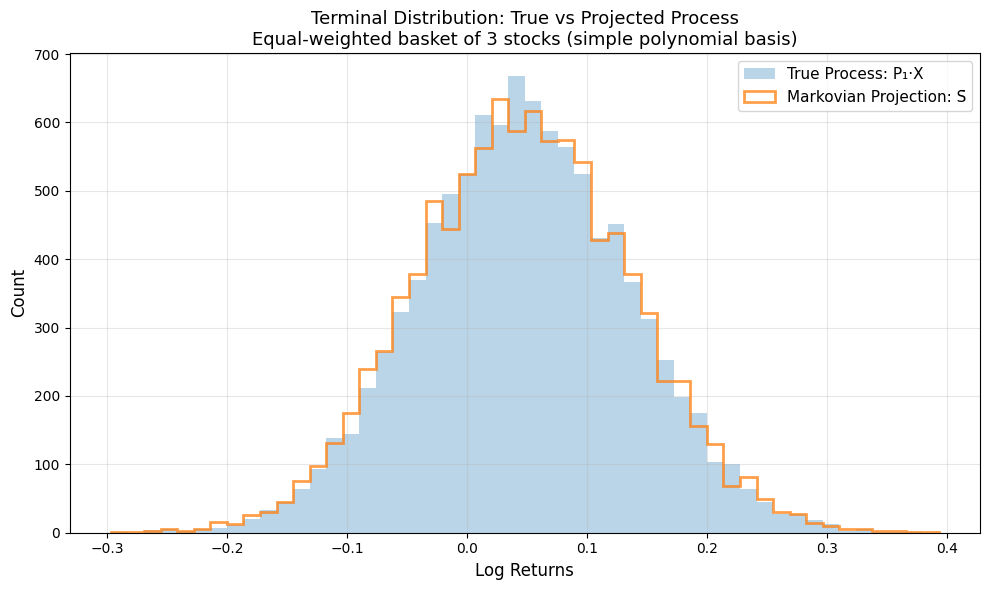

In [19]:
plot_comparison(log_returns_basket, log_returns_S_bar, params)